In [1]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *
from src.model.models import MLPWithDropout, MLPWithDropoutBN

In [2]:
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_2017-24.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [3]:
seasons=sorted(TRAINGING_CONFIG['seasons'])
target_dfs=[pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=TRAINGING_CONFIG['key_columns']).columns.tolist()

In [4]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

In [5]:
param_grid = {
    'model_params.hidden_layers': [(512, 256, 256, 128, 128)],
    'model_params.activation': ['relu'],
    'model_params.dropout_rate': [0],
    'learning_rate': [0.00001],
    'batch_size': [64],
    'epochs': [5000]
}


In [6]:
feature_df.fillna(-1, inplace=True)

In [7]:
numeric_cols = feature_df.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
feature_df[numeric_cols] = scaler.fit_transform(feature_df[numeric_cols])

In [8]:
feature_df.shape

(2280, 2729)

Training MLPwithDropoutBN on home_goals with param grid: {'model_params.hidden_layers': [(512, 256, 256, 128, 128)], 'model_params.activation': ['relu'], 'model_params.dropout_rate': [0], 'learning_rate': [1e-05], 'batch_size': [64], 'epochs': [5000]}
Using range-based class conversion with range: (0, 5)
Training fold 1/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


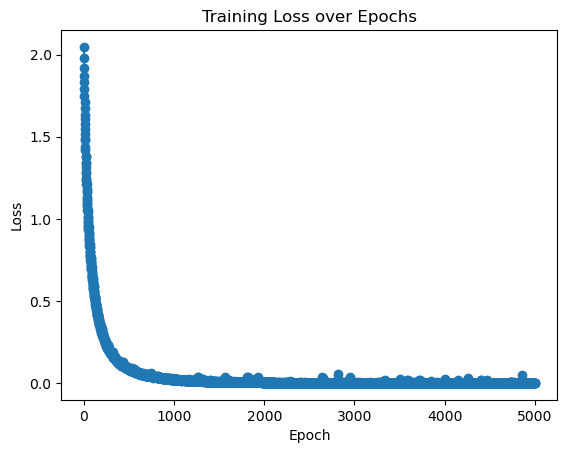

Final training loss: 0.00046856504523233453
Training fold 2/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


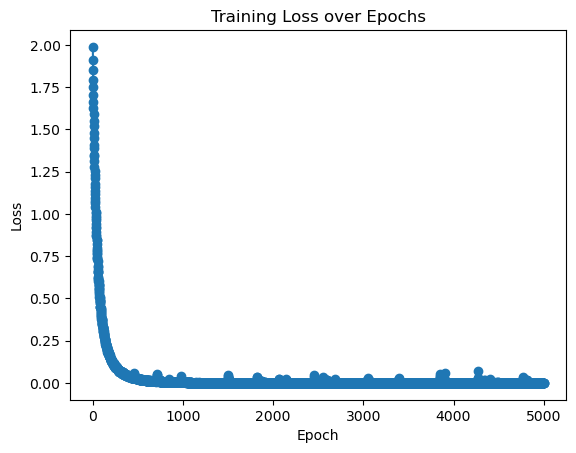

Final training loss: 0.00019609638182065117
Training fold 3/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


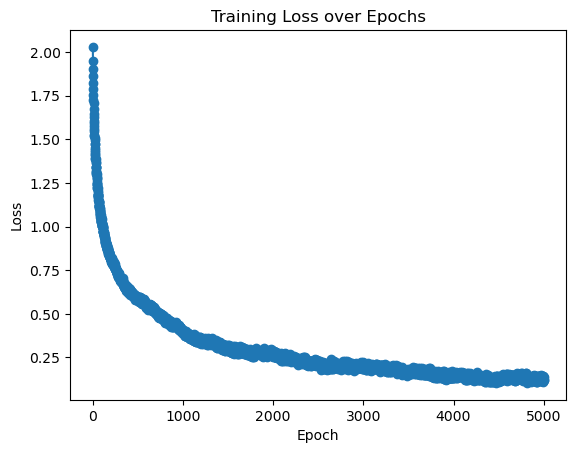

Final training loss: 0.12119905351430585
Training fold 4/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


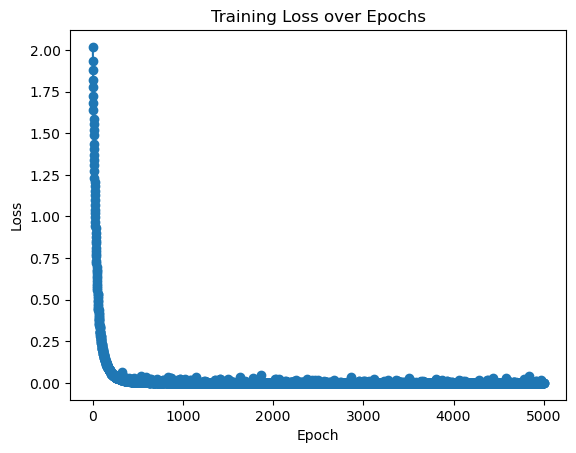

Final training loss: 0.00029577073513132614
Training fold 5/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


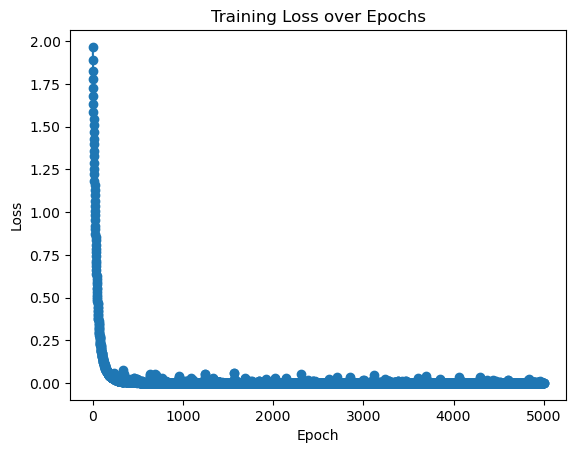

Final training loss: 0.0007790771243570927
[TorchWrapper] Using device: mps


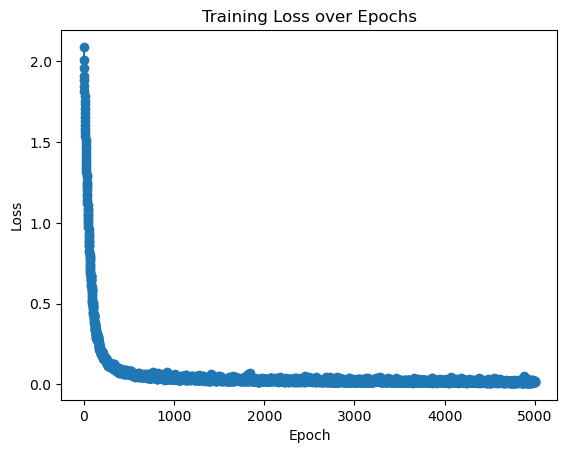

Final training loss: 0.021935187498031306
{'home_goals_train_accuracy': 0.9928849902534113, 'home_goals_train_precision': 0.7895306906207396, 'home_goals_valid_accuracy': 0.2807017543859649, 'home_goals_valid_precision': 0.1297740758022219, 'home_goals_test_accuracy': 0.22807017543859648, 'home_goals_test_precision': 0.1532985287138111, 'home_goals_train_lte_0_accuracy': 0.9916981132075472, 'home_goals_train_lte_0_accuracy_std': 0.016603773584905657, 'home_goals_train_lte_0_precision': 0.8400000000000001, 'home_goals_train_lte_0_precision_std': 0.32, 'home_goals_train_gt_1_accuracy': 0.9888658693514166, 'home_goals_train_gt_1_accuracy_std': 0.013738732042509798, 'home_goals_train_gt_1_precision': 0.7042263149074295, 'home_goals_train_gt_1_precision_std': 0.17362072513507315, 'home_goals_train_gt_2_accuracy': 0.9814454612600116, 'home_goals_train_gt_2_accuracy_std': 0.018411924749093943, 'home_goals_train_gt_2_precision': 0.6492117758784426, 'home_goals_train_gt_2_precision_std': 0.2077

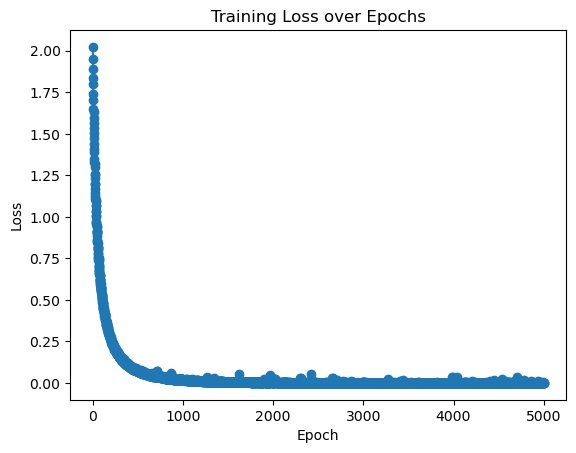

Final training loss: 0.0006715444230463639
Training fold 2/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


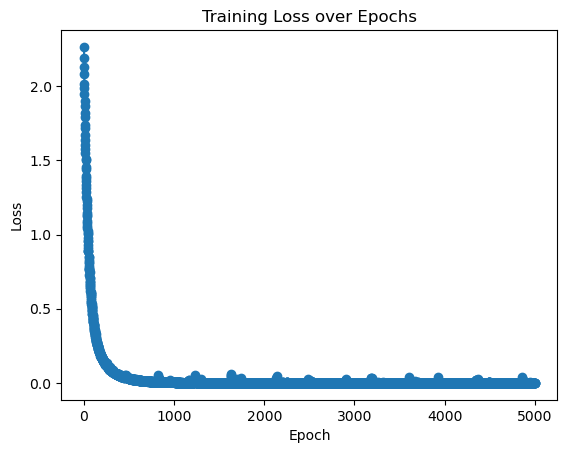

Final training loss: 0.00030270677498318475
Training fold 3/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


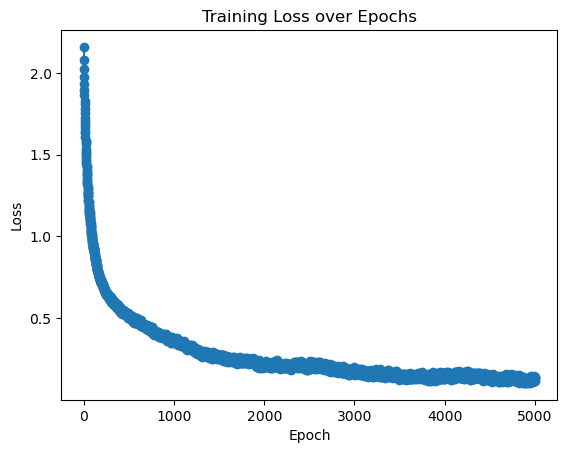

Final training loss: 0.13194581732647692
Training fold 4/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


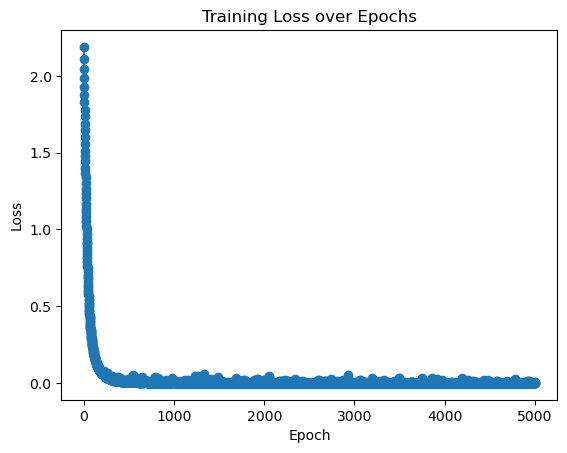

Final training loss: 0.0005082713408744213
Training fold 5/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


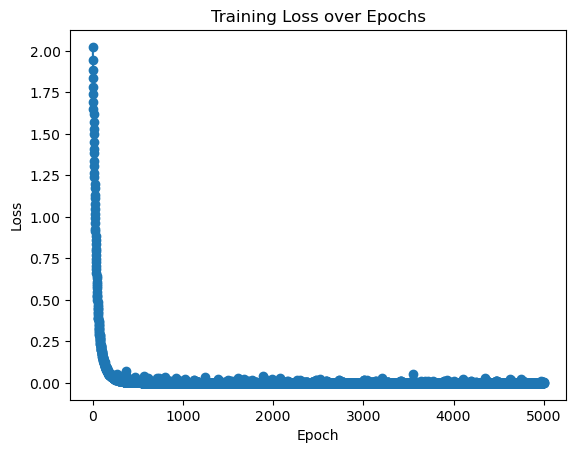

Final training loss: 0.0005330137318212604
[TorchWrapper] Using device: mps


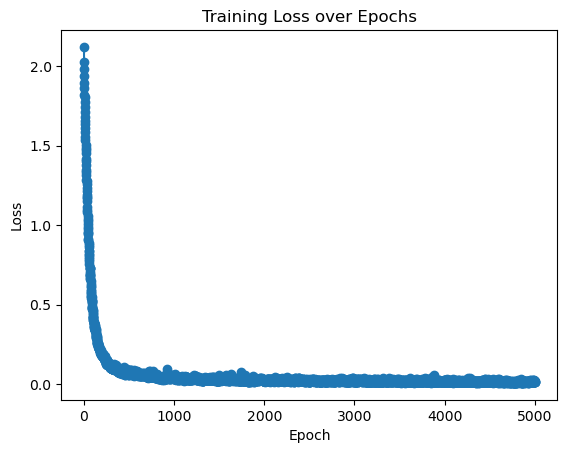

Final training loss: 0.01990732175187293
{'away_goals_train_accuracy': 0.9969103313840156, 'away_goals_train_precision': 0.854581819590963, 'away_goals_valid_accuracy': 0.29239766081871343, 'away_goals_valid_precision': 0.1330825739499109, 'away_goals_test_accuracy': 0.19736842105263158, 'away_goals_test_precision': 0.11034798534798533, 'away_goals_train_lte_0_accuracy': 1.0, 'away_goals_train_lte_0_accuracy_std': 0.0, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_gt_1_accuracy': 0.9909341999553369, 'away_goals_train_gt_1_accuracy_std': 0.014157408222196776, 'away_goals_train_gt_1_precision': 0.778843430956107, 'away_goals_train_gt_1_precision_std': 0.12820939991133984, 'away_goals_train_gt_2_accuracy': 0.9811142786634104, 'away_goals_train_gt_2_accuracy_std': 0.02708966699330612, 'away_goals_train_gt_2_precision': 0.7333333333333333, 'away_goals_train_gt_2_precision_std': 0.16158932858054428, 'away_goals_train_gt_3_accuracy': 0

In [9]:

run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TRAINGING_CONFIG['target_ranges'],
    model_wrapper_class=lambda **params: TorchWrapper(
        model_class=MLPWithDropoutBN,
        model_params={k.replace('model_params.', ''): v for k, v in params.items() if k.startswith('model_params.')},
        learning_rate=params.get('learning_rate', 0.001),
        batch_size=params.get('batch_size', 64),
        epochs=params.get('epochs', 20)
    ),
    model_param_grid=param_grid,
    test_size=TRAINGING_CONFIG['test_size'],
    k=5,
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    uri=f'{REPO_PATH}/mlflow',
    model_name='MLPwithDropoutBN',
    key_columns=TRAINGING_CONFIG['key_columns'],
)

/Users/tianqihuang/Documents/GitHub/betbot/src/model/experiment_utils.py:127: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.show()


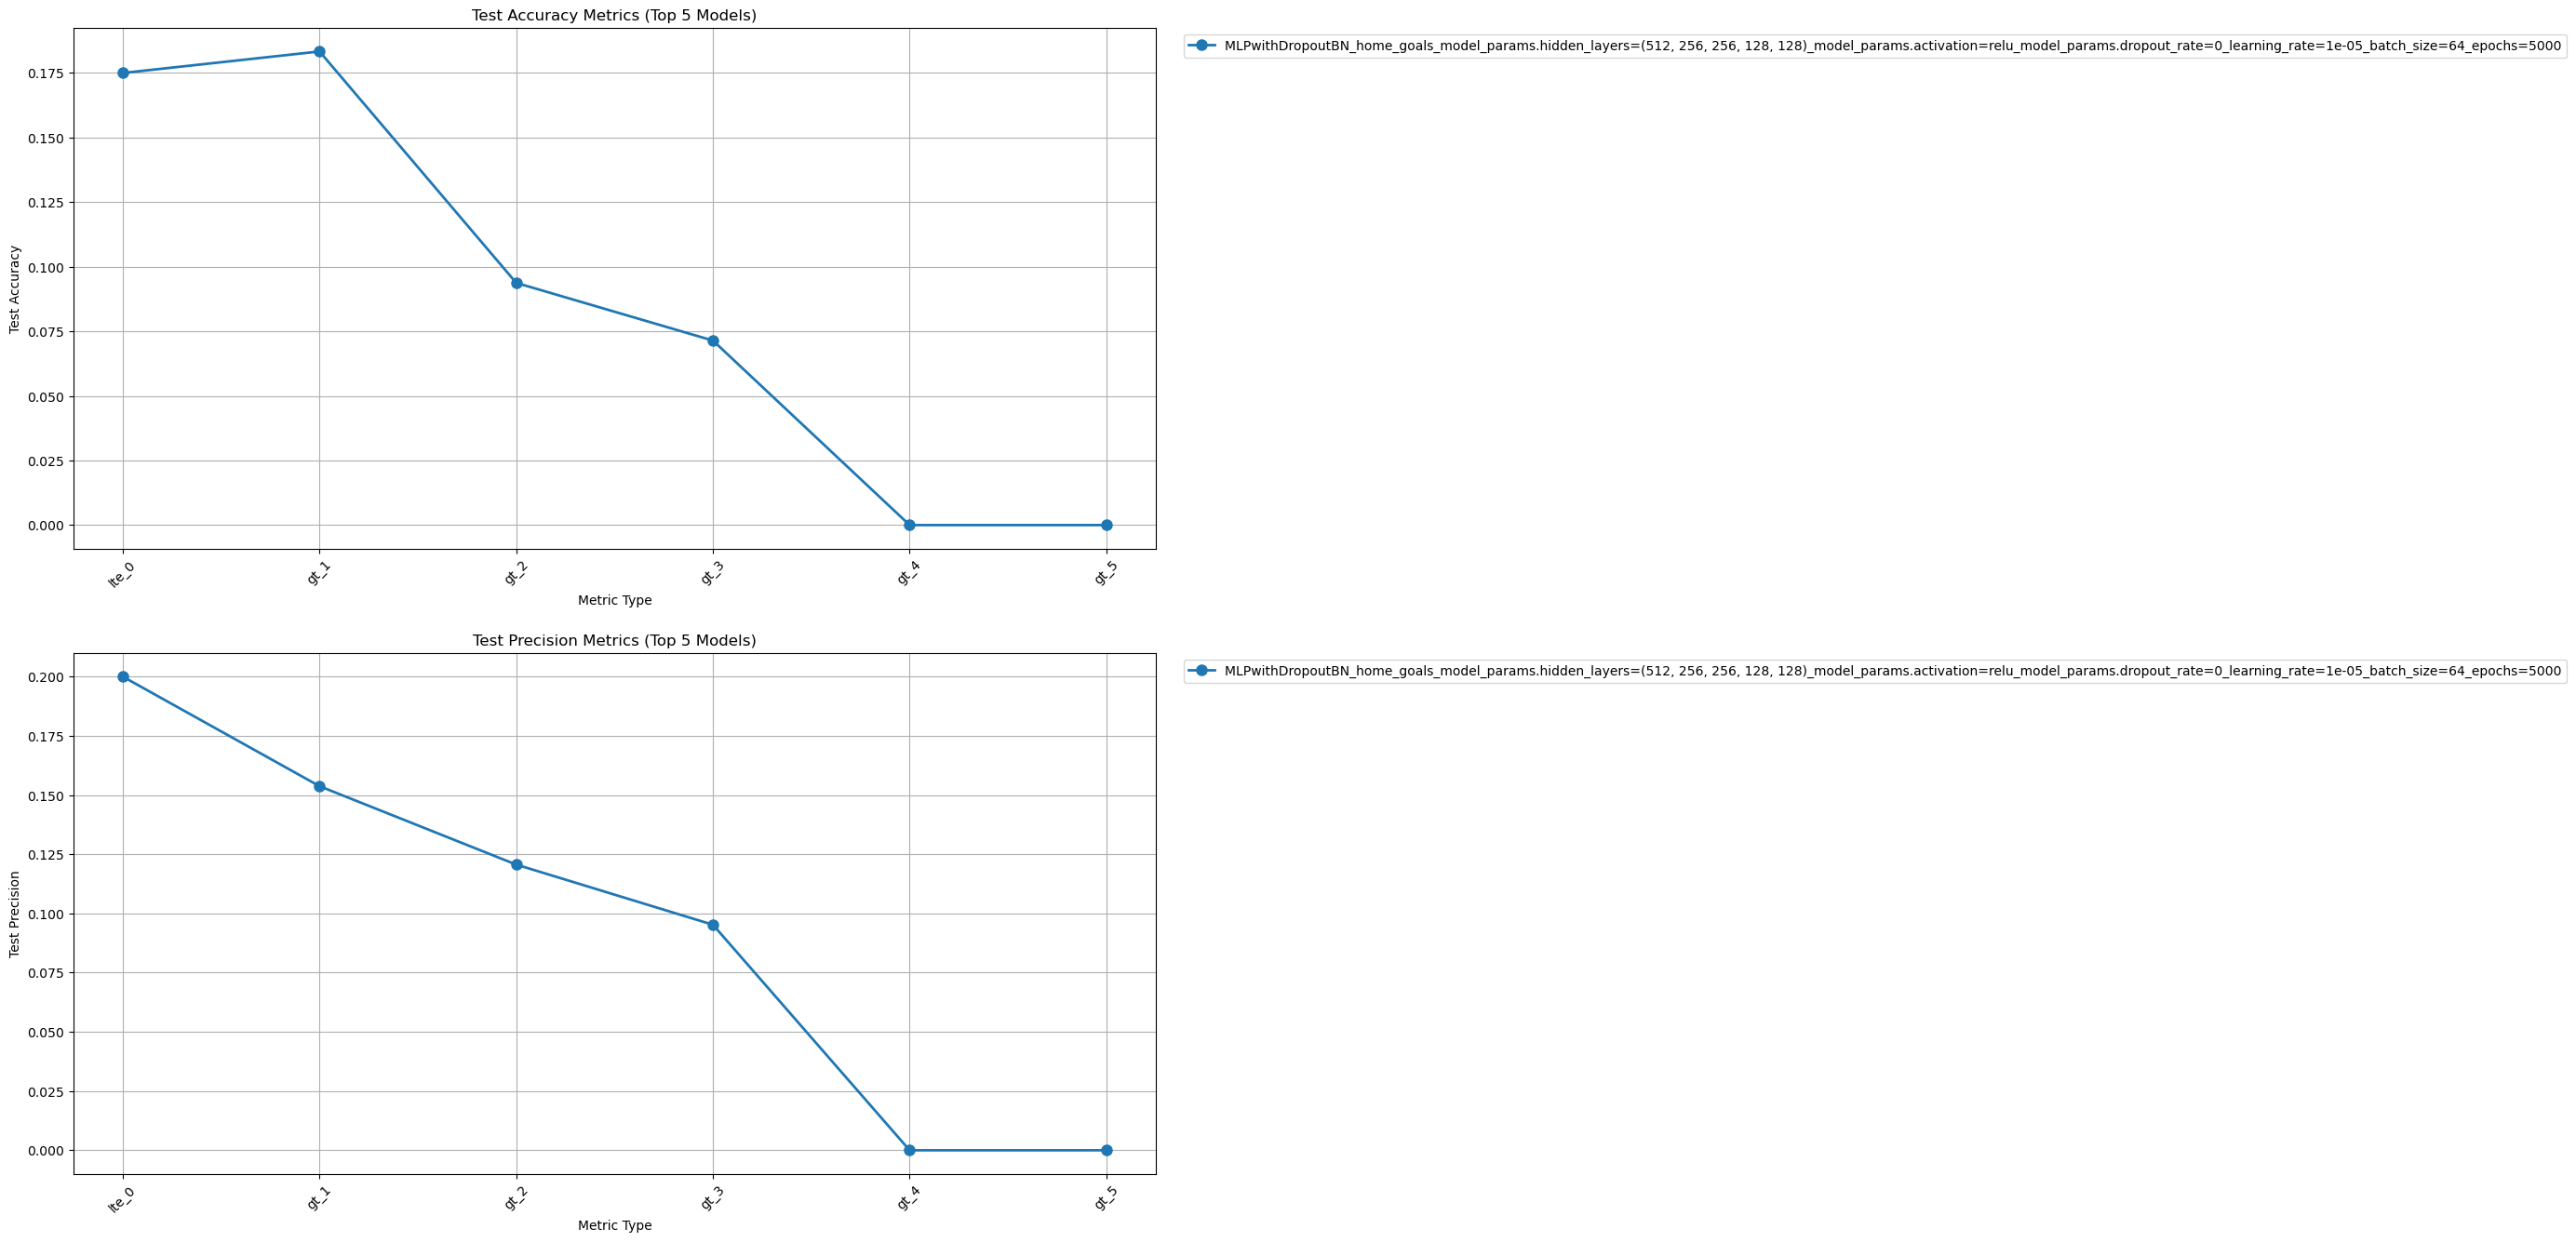

In [10]:
plot_metrics_for_target_and_model(
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    target_col="home_goals",
    model_name="MLPwithDropoutBN",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

In [13]:
plot_run_metrics_by_split(experiment_name=TRAINGING_CONFIG['experiment_name'],
                         run_name="MLPwithDropoutBN_away_goals_{'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}",
                         target_col="home_goals",
                         tracking_uri=f"{REPO_PATH}/mlflow")

MlflowException: Invalid clause(s) in filter string: 'tags.mlflow.runName = 'MLPwithDropoutBN_away_goals_{'model_params.hidden_layers', '': (512, 256, 256, 128, 128), '', 'model_params.activation', '': '', 'relu', '', '', 'model_params.dropout_rate', '': 0, '', 'learning_rate', '': 1e-05, '', 'batch_size', '': 64, '', 'epochs', '': 5000}''

In [ ]:
plot_run_metrics_side_by_side(experiment_name=TRAINGING_CONFIG['experiment_name'],
                              model_name="MLPwithDropoutBN",
                              model_param={'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.00001, 'batch_size': 64, 'epochs': 5000},
                              tracking_uri=f"{REPO_PATH}/mlflow",
                              metric_type="precision")

Searching for runs with filter: params.model_name = 'MLPwithDropoutBN' and params.model_params.hidden_layers: '(512, 256, 256, 128, 128)' and params.model_params.activation: 'relu' and params.model_params.dropout_rate: '0' and params.learning_rate: '1e-05' and params.batch_size: '64' and params.epochs: '5000'


MlflowException: Invalid clause(s) in filter string: 'params.model_params.hidden_layers', ':', ''(512, 256, 256, 128, 128)'', 'params.model_params.activation', ':', ''relu'', 'params.model_params.dropout_rate', ':', ''0'', 'params.learning_rate', ':', ''1e-05'', 'params.batch_size', ':', ''64'', 'params.epochs', ':', ''5000''